In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())
    print("CUDA version:", torch.version.cuda)

PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4
GPU count: 1
CUDA version: 13.0


In [3]:
!nvidia-smi

Tue Oct  6 03:42:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import torch
import torch.nn as nn

device = torch.device("cuda")

N = 1_000_000
F = 100

X = torch.randn(N, F).to(device)
y = torch.randint(0, 2, (N, 1)).float().to(device)

model = nn.Linear(F, 1).to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

print("X shape :", X.shape)
print("X device:", X.device)
print("y shape :", y.shape)
print("Model device:", model.weight.device)

print("\nGPU memory allocated:",
      round(torch.cuda.memory_allocated() / 1024**2, 2), "MB")

X shape : torch.Size([1000000, 100])
X device: cuda:0
y shape : torch.Size([1000000, 1])
Model device: cuda:0

GPU memory allocated: 385.82 MB


In [5]:
!nvidia-smi

Tue Oct  6 03:46:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P0             32W /   70W |     509MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
from torch.profiler import profile, ProfilerActivity

# Warm-up runs
for _ in range(5):
    optimizer.zero_grad()
    logits = model(X)
    loss = loss_fn(logits, y)
    loss.backward()
    optimizer.step()

torch.cuda.synchronize()

with profile(
    activities=[
        ProfilerActivity.CPU,
        ProfilerActivity.CUDA
    ],
    record_shapes=True
) as prof:

    optimizer.zero_grad()

    logits = model(X)
    loss = loss_fn(logits, y)

    loss.backward()
    optimizer.step()

torch.cuda.synchronize()

print(
    prof.key_averages().table(
        sort_by="self_cuda_time_total",
        row_limit=15
    )
)

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                            aten::addmm         8.16%       1.139ms        24.01%       3.354ms       3.354ms       2.503ms        55.94%       5.005ms       5.005ms             1  
                                Activity Buffer Request        28.71%       4.012ms        28.71%       4.012ms       2.006ms       2.503ms        55.94%       2.503ms       1.251ms             2  
void gemv

/usr/local/lib/python3.13/dist-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


In [7]:
import time

def measure_batch_size(batch_size):

    torch.cuda.synchronize()
    start = time.perf_counter()

    for start_idx in range(0, N, batch_size):

        end_idx = min(start_idx + batch_size, N)

        X_batch = X[start_idx:end_idx]
        y_batch = y[start_idx:end_idx]

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        loss.backward()
        optimizer.step()

    torch.cuda.synchronize()
    end = time.perf_counter()

    elapsed = end - start
    throughput = N / elapsed

    return elapsed, throughput


batch_sizes = [1000, 10000, 100000, 1000000]

for batch_size in batch_sizes:

    elapsed, throughput = measure_batch_size(batch_size)

    print(
        f"Batch size: {batch_size:>7} | "
        f"Time: {elapsed:.4f} sec | "
        f"Throughput: {throughput:,.0f} samples/sec"
    )

Batch size:    1000 | Time: 0.8632 sec | Throughput: 1,158,480 samples/sec
Batch size:   10000 | Time: 0.0850 sec | Throughput: 11,770,085 samples/sec
Batch size:  100000 | Time: 0.0089 sec | Throughput: 112,449,712 samples/sec
Batch size: 1000000 | Time: 0.0047 sec | Throughput: 213,344,166 samples/sec


In [8]:
from torch.profiler import profile, ProfilerActivity

# Warm-up
for _ in range(5):
    optimizer.zero_grad()
    logits = model(X)
    loss = loss_fn(logits, y)
    loss.backward()
    optimizer.step()

torch.cuda.synchronize()

with profile(
    activities=[
        ProfilerActivity.CPU,
        ProfilerActivity.CUDA
    ],
    record_shapes=True
) as prof_optimized:

    optimizer.zero_grad()
    logits = model(X)
    loss = loss_fn(logits, y)
    loss.backward()
    optimizer.step()

torch.cuda.synchronize()

print(
    prof_optimized.key_averages().table(
        sort_by="self_cuda_time_total",
        row_limit=15
    )
)

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                            aten::addmm         1.87%     118.227us        36.00%       2.281ms       2.281ms       2.497ms        55.89%       4.995ms       4.995ms             1  
                                Activity Buffer Request        33.26%       2.107ms        33.26%       2.107ms       2.107ms       2.497ms        55.89%       2.497ms       2.497ms             1  
void gemv

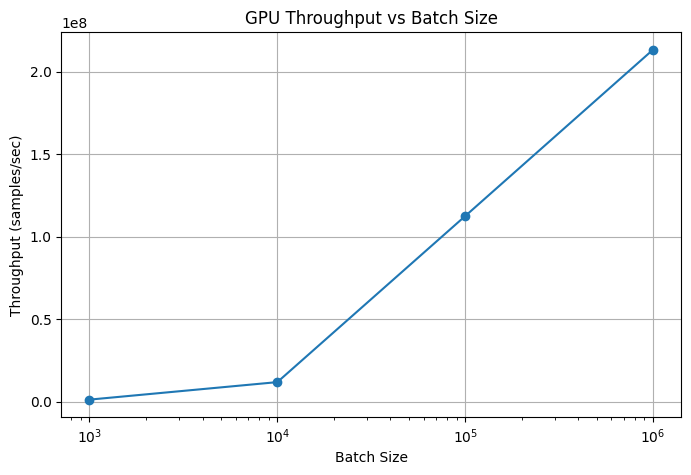

In [9]:
import matplotlib.pyplot as plt

batch_sizes = [1000, 10000, 100000, 1000000]
throughputs = [
    1158480,
    11770085,
    112449712,
    213344166
]

plt.figure(figsize=(8, 5))
plt.plot(batch_sizes, throughputs, marker="o")
plt.xscale("log")

plt.xlabel("Batch Size")
plt.ylabel("Throughput (samples/sec)")
plt.title("GPU Throughput vs Batch Size")

plt.grid(True)
plt.show()

In [10]:
small_batch_throughput = 1_158_480
large_batch_throughput = 213_344_166

improvement = large_batch_throughput / small_batch_throughput

print("=== COLAB 3 RESULTS ===")

print("\nProfiler finding:")
print("aten::addmm ≈ 56% of self CUDA time")
print("aten::mm    ≈ 35% of self CUDA time")

print("\nBatch-size experiment:")
print(f"Batch 1,000 throughput:     {small_batch_throughput:,.0f} samples/sec")
print(f"Batch 1,000,000 throughput: {large_batch_throughput:,.0f} samples/sec")
print(f"Throughput improvement:     {improvement:.1f}x")

print("\nConclusion:")
print("Small batches incurred substantial repeated execution overhead.")
print("Larger batches exposed more parallel work to the GPU and greatly increased throughput.")
print("The dominant useful CUDA computation remained the model's linear algebra operations.")

=== COLAB 3 RESULTS ===

Profiler finding:
aten::addmm ≈ 56% of self CUDA time
aten::mm    ≈ 35% of self CUDA time

Batch-size experiment:
Batch 1,000 throughput:     1,158,480 samples/sec
Batch 1,000,000 throughput: 213,344,166 samples/sec
Throughput improvement:     184.2x

Conclusion:
Small batches incurred substantial repeated execution overhead.
Larger batches exposed more parallel work to the GPU and greatly increased throughput.
The dominant useful CUDA computation remained the model's linear algebra operations.
